<div style="background:#FFF5F8;border:3px solid #E0218A;border-radius:16px;padding:28px;text-align:center;">
<h1 style="color:#E0218A;margin:0;">🐥 Curso de Machine Learning · Clase 2 de 7</h1>
<h2 style="color:#1B2A5B;margin:10px 0 4px;">Supervisado o no supervisado, el mapa que evita el 80% de los errores</h2>
<p style="color:#1B2A5B;margin:6px 0;">Con la Miss Yera · <a href="https://missyera.com">missyera.com</a> · @soymissyera</p>
<p style="color:#E0218A;margin:0;"><b>Regla de oro del curso, nadie ejecuta una celda sin predecir en voz alta qué va a pasar.</b></p>
</div>

## 🧭 ¿Dónde estamos en el curso?

Progreso, 🐥🐥▫️▫️▫️▫️▫️ · clase 2 de 7

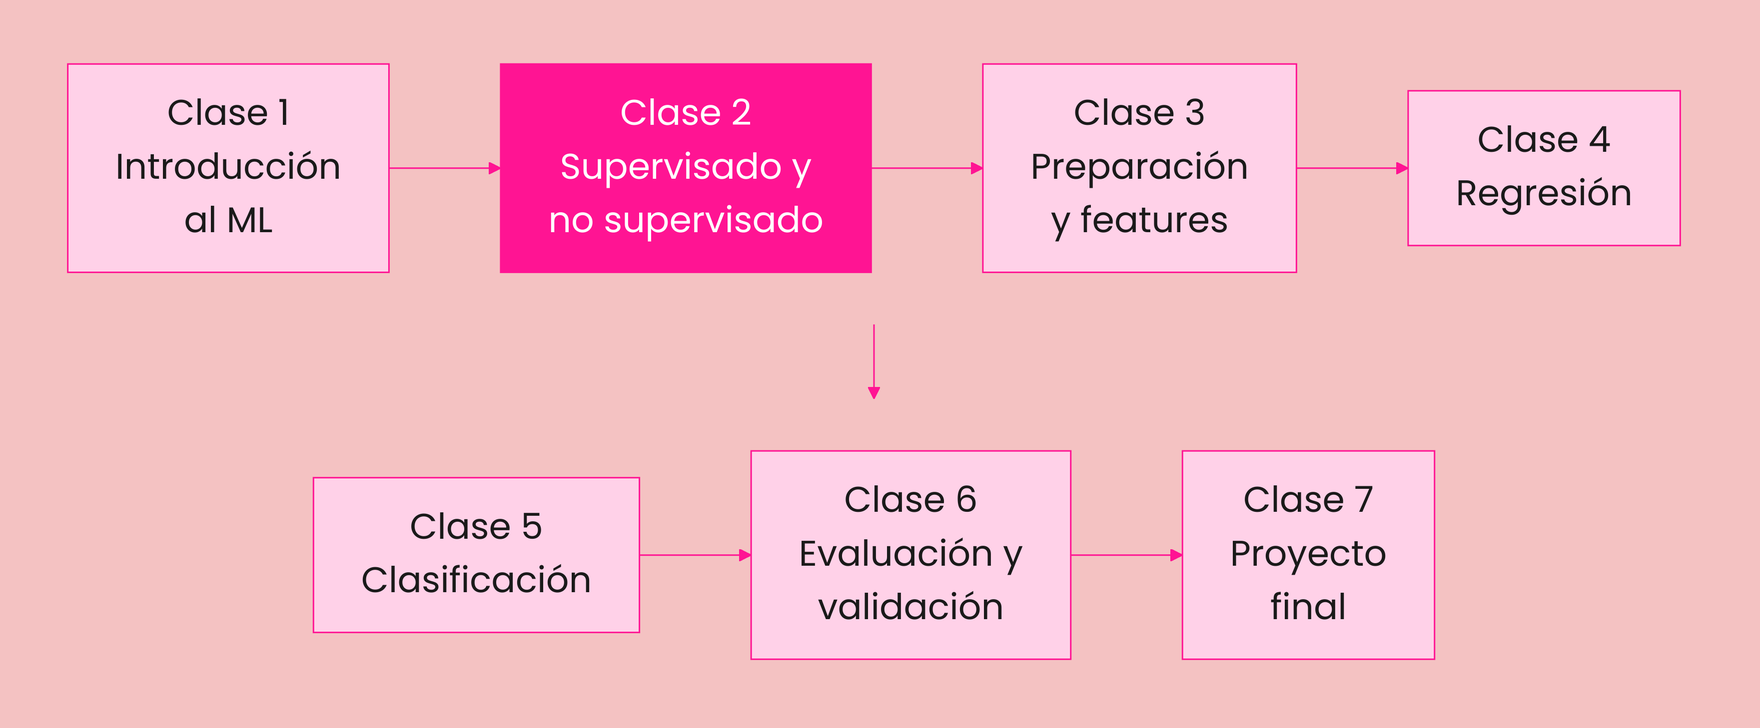


## 🔁 Antes de arrancar, 60 segundos de la clase anterior

En la clase 1, tu primera predicción, ¿a quién le presta pollicreditos?, dejamos lista la base para lo de hoy. Si algo de lo que sigue no te suena, regresa a ese notebook o al video de la clase 1 de la playlist antes de continuar.


In [ ]:
#@title 🎬 Toca play · Quiz de entrada, ¿qué te llevaste de la clase anterior?
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de entrada, ¿qué te llevaste de la clase anterior?</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. ¿El machine learning recibe reglas o las aprende?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin2_0" value="0"> Recibe las reglas escritas por el programador</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin2_0" value="1"> Las aprende desde los datos y las respuestas</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin2_0" value="2"> No usa reglas de ningún tipo</label><div id="qin2_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. En PolliCreditos, ¿qué es la y del problema de aprobación?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin2_1" value="0"> El ingreso del cliente</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin2_1" value="1"> La deuda del cliente</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin2_1" value="2"> Si pagó o no pagó, la respuesta a aprender</label><div id="qin2_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "recuerda el diagrama de reglas contra datos"], [2, "y es la respuesta correcta que el modelo debe aprender"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qin2_"+i+"\']:checked");
        var fb=document.getElementById("qin2_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🎯 Lo que vas a lograr hoy

- Decidir con una sola pregunta si tu problema es supervisado o no supervisado.
- Distinguir clasificación de regresión y elegir la correcta según lo que quieres predecir.
- Ver a KMeans descubrir segmentos de clientes sin que nadie le diga la respuesta.


## 📩 El pedido de la semana en PolliCreditos

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><i>"Antes de prestar más quiero entender qué tipos de clientes tenemos, y de paso ordenar los pedidos del equipo, ¿cuáles son problemas supervisados y cuáles no?"</i><br><b style="color:#1B2A5B;">El CEO de PolliCreditos 🐥</b></div>



<div style="background: linear-gradient(135deg, #FF1493 0%, #FF69B4 55%, #FFB6C1 100%); border-radius: 22px; padding: 42px 36px; text-align: center; color: white; font-family: 'Inter', sans-serif;">
  <div style="font-size: 15px; letter-spacing: 3px; opacity: .95;">🐤 CURSO DE MACHINE LEARNING · CLASE 02</div>
  <h1 style="margin: 14px 0 6px 0; font-size: 40px; color: white;">Aprendizaje supervisado y no supervisado</h1>
  <div style="font-size: 18px; opacity: .96;">Los dos grandes caminos, aprender con maestro o descubrir solo</div>
  <div style="margin-top: 22px; font-size: 14px; background: rgba(255,255,255,.18); display: inline-block; padding: 8px 20px; border-radius: 999px;">Miss Yera · missyera.com · @soymissyera</div>
</div>



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 17px;">🎯 Al final de esta clase vas a poder</b>
<ul style="margin-top: 10px;"><li>Distinguir supervisado de no supervisado con criterio claro</li>
<li>Diferenciar clasificación de regresión dentro del supervisado</li>
<li>Ver clustering en acción con KMeans sobre clientes</li>
<li>Elegir el enfoque correcto para un problema real</li></ul>
</div>


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta oficial Miss Yera para todos los gráficos de la clase
YERA = ['#FF1493', '#FF69B4', '#FFB6C1', '#00C9A7', '#FFC75F', '#1B2A5B']
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.prop_cycle': plt.cycler(color=['#FF1493', '#00C9A7', '#1B2A5B', '#FFC75F', '#FF69B4']),
})
np.random.seed(42)  # semilla fija, reproducible o no existe
print('Setup listo, pollito 🐥')


<div style="background: #FFF5F8; border: 2px dashed #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#1B2A5B; font-size: 16px;">📖 Concepto nuevo, <span style="color:#FF1493;">Aprendizaje supervisado</span></b><br>
El dataset incluye la respuesta correcta, el target, para cada ejemplo. El modelo aprende la relación entre features y target para predecir casos nuevos.<br>
<i>🐥 En idioma pollito, Es estudiar con solucionario. El pollito ve mil ejercicios con su respuesta y aprende el método, luego rinde el examen con ejercicios nuevos.</i>
</div>



<div style="background: #FFF5F8; border: 2px dashed #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#1B2A5B; font-size: 16px;">📖 Concepto nuevo, <span style="color:#FF1493;">Aprendizaje no supervisado</span></b><br>
No hay target. El modelo busca estructura oculta en los datos, grupos, patrones o anomalías, sin que nadie le diga la respuesta.<br>
<i>🐥 En idioma pollito, Es ordenar tu ropero sin instrucciones. Nadie te dijo las categorías, pero al terminar hay un montón de polos, otro de jeans y otro de vestidos. Los grupos emergieron solos.</i>
</div>


## 1. El mapa de decisión

```text
¿Tu dataset tiene la columna respuesta (target)?
│
├── SÍ → SUPERVISADO
│    ├── ¿El target es una categoría?  → CLASIFICACIÓN  (paga o no, spam o no, gato o perro)
│    └── ¿El target es un número?      → REGRESIÓN      (precio, demanda, temperatura)
│
└── NO → NO SUPERVISADO
     ├── ¿Buscas grupos parecidos?     → CLUSTERING     (segmentos de clientes)
     ├── ¿Buscas lo raro?              → ANOMALÍAS      (fraude, fallas)
     └── ¿Quieres comprimir variables? → REDUCCIÓN DE DIMENSIONES  (PCA)
```

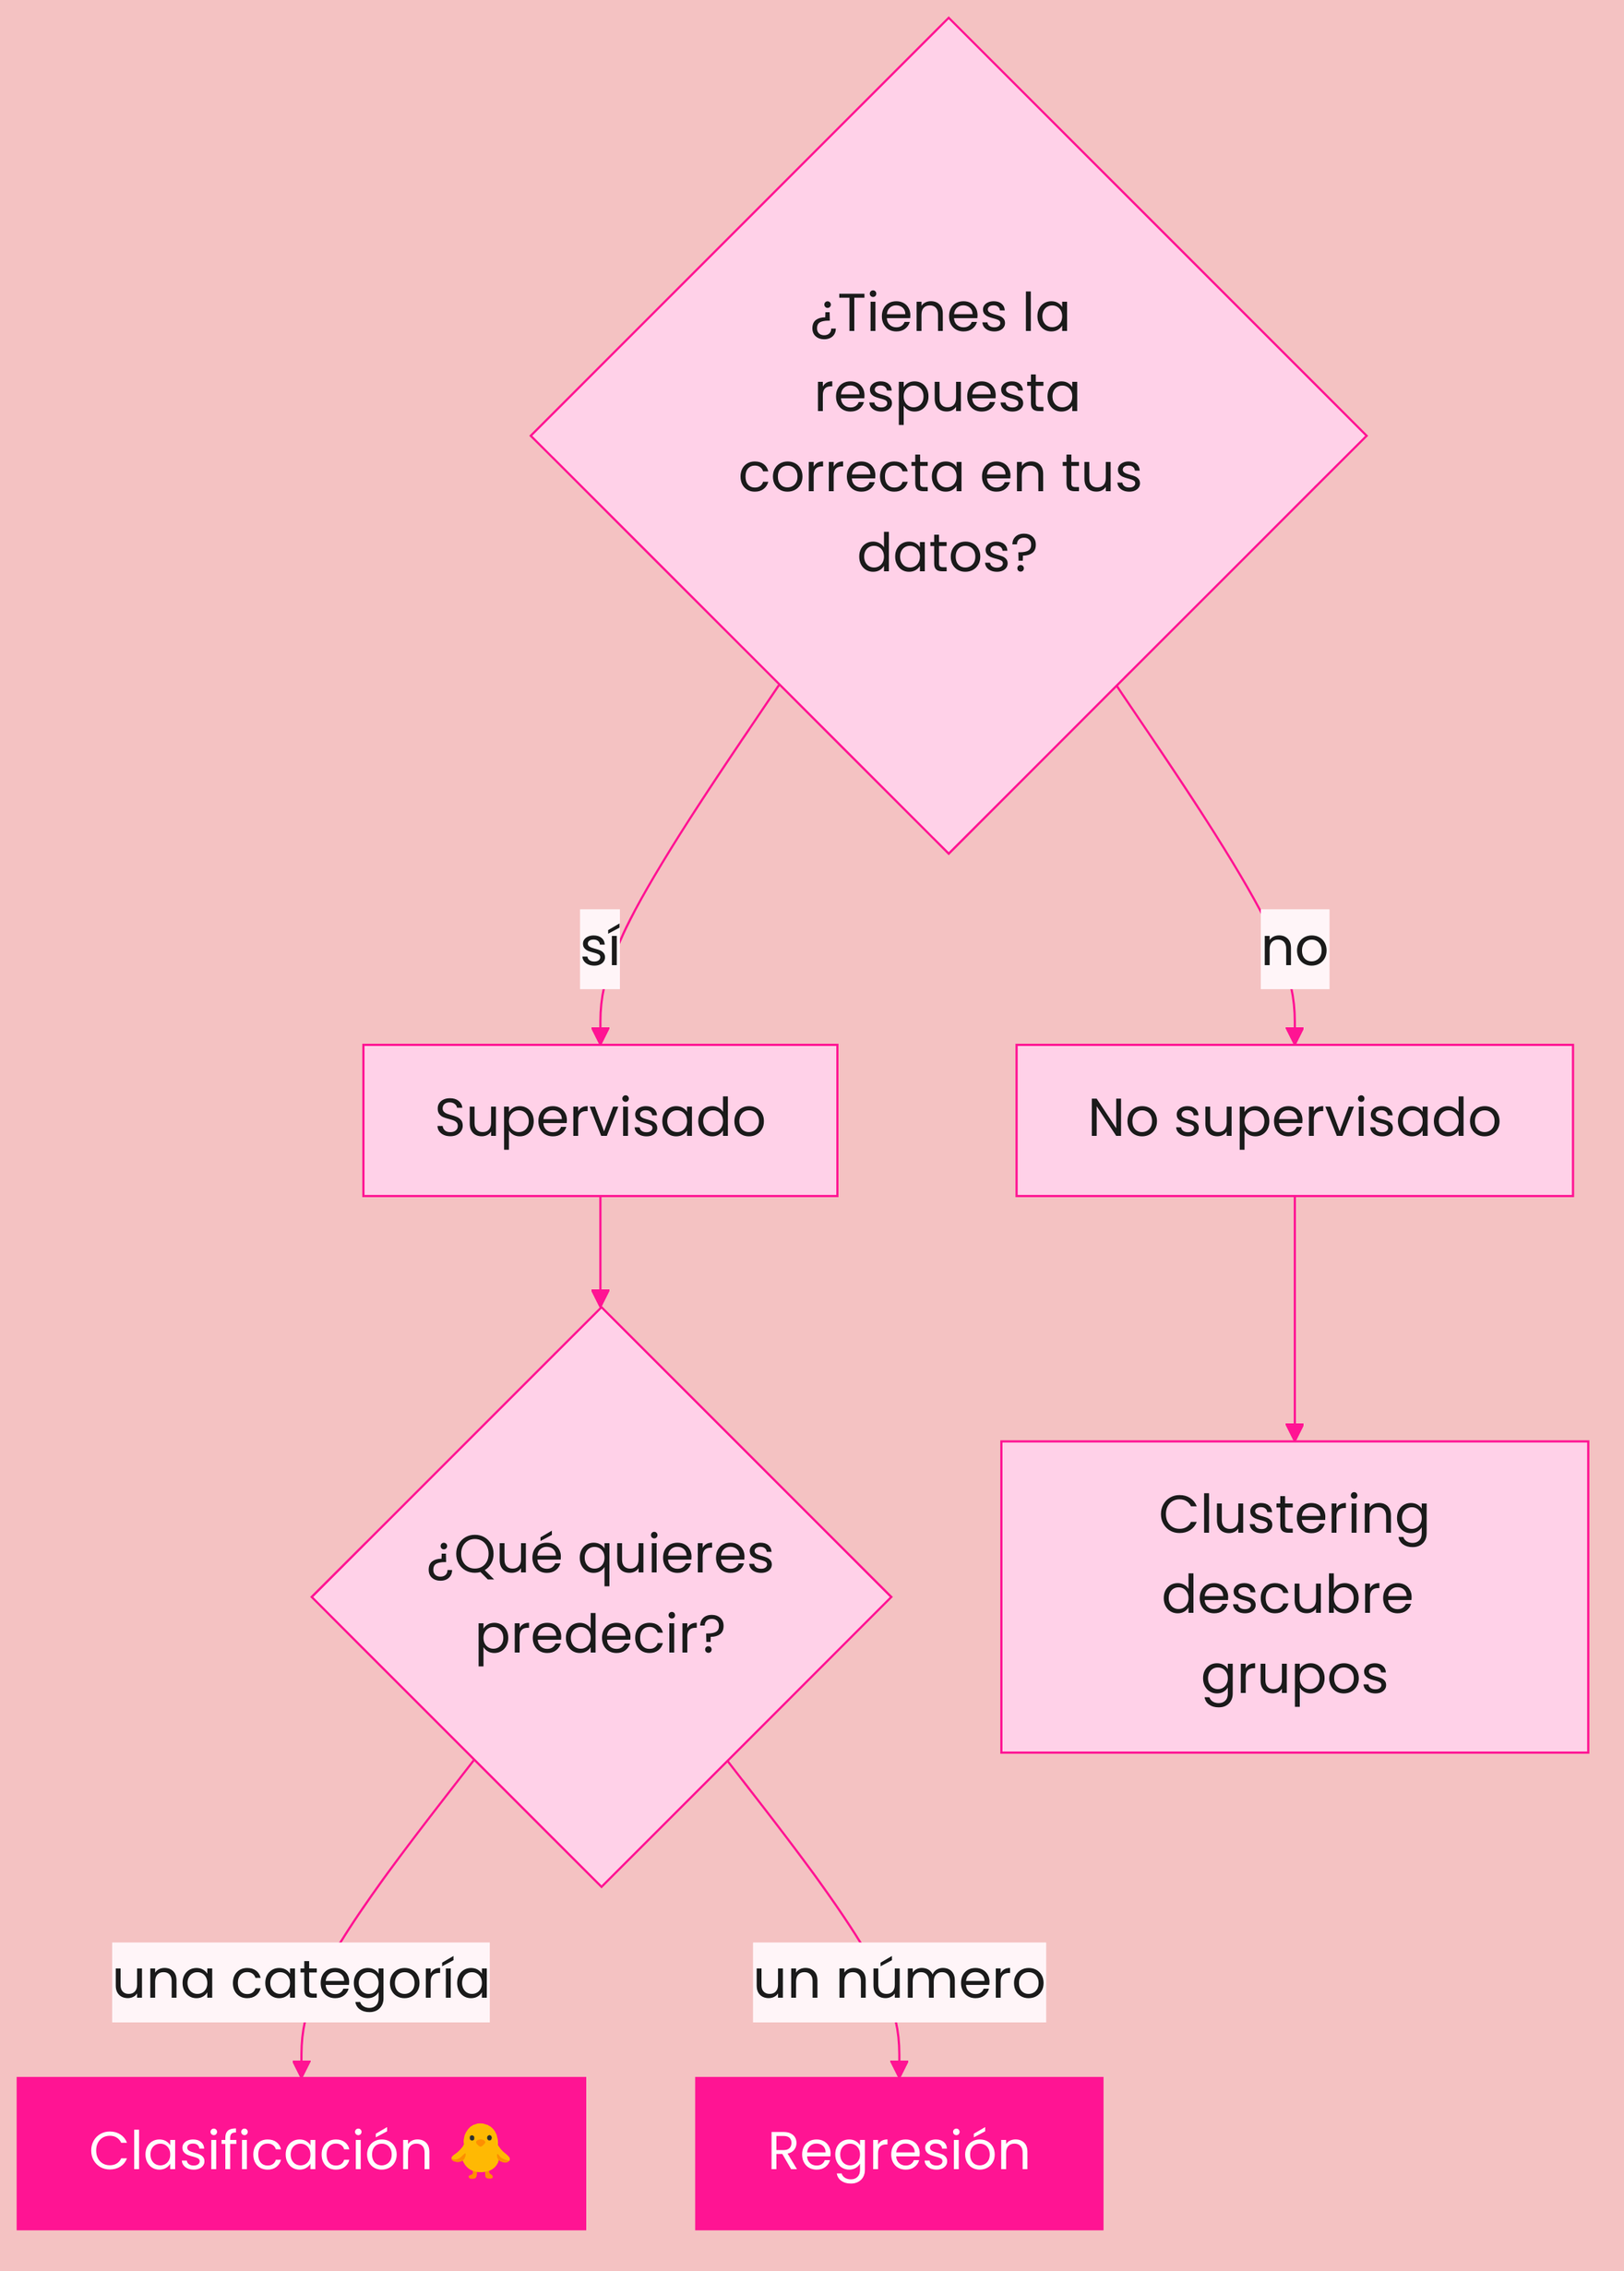

*Una sola pregunta ordena todo el mapa, ¿tienes la respuesta correcta en tus datos?.*


## 2. Supervisado en acción, clasificación y regresión lado a lado

In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# CLASIFICACIÓN, el target es una categoría, renueva o no renueva
meses_de_cliente = np.random.uniform(1, 30, 150)
creditos_pagados = np.random.randint(1, 15, 150)
renueva = ((meses_de_cliente * creditos_pagados + np.random.normal(0, 20, 150)) > 80).astype(int)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.____(np.column_stack([meses_de_cliente, creditos_pagados]), renueva)
print("CLASIFICACIÓN, visitante de 12 min y 8 páginas →",
      "🛒 comprará" if clf.____([[12, 8]])[0] else "👀 solo mira")

# REGRESIÓN, el target es un número, el monto del crédito según los metros del local
metros = np.random.uniform(40, 150, 150)
precio_miles = 30 + 2.8 * metros + np.random.normal(0, 25, 150)

reg = LinearRegression()
reg.____(metros.reshape(-1, 1), precio_miles)
pred = reg.____([[90]])[0]
print(f"REGRESIÓN, depa de 90 m² → precio estimado S/ {pred*1000:,.0f}")
print(f"           cada m² extra suma S/ {reg.coef_[0]*1000:,.0f} al precio")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués de esta celda</b><br>
Mismo esqueleto, fit y predict, distinta naturaleza del target. La clasificación responde con una etiqueta, la regresión con un número continuo. Elegir mal entre las dos es el error número uno de los principiantes, y se evita con una sola pregunta, ¿la respuesta es categoría o cantidad?
</div>


## 3. No supervisado en acción, KMeans descubre segmentos de clientes

Una tienda tiene datos de sus clientes pero nadie los ha segmentado. KMeans va a descubrir los grupos sin que le digamos cuáles son.

### 🧮 La matemática detrás · Geometría, el Pitágoras de las distancias

$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$

**Lectura en palabras,** la distancia entre dos clientes es el Pitágoras de toda la vida, KMeans agrupa a los que están cerca.

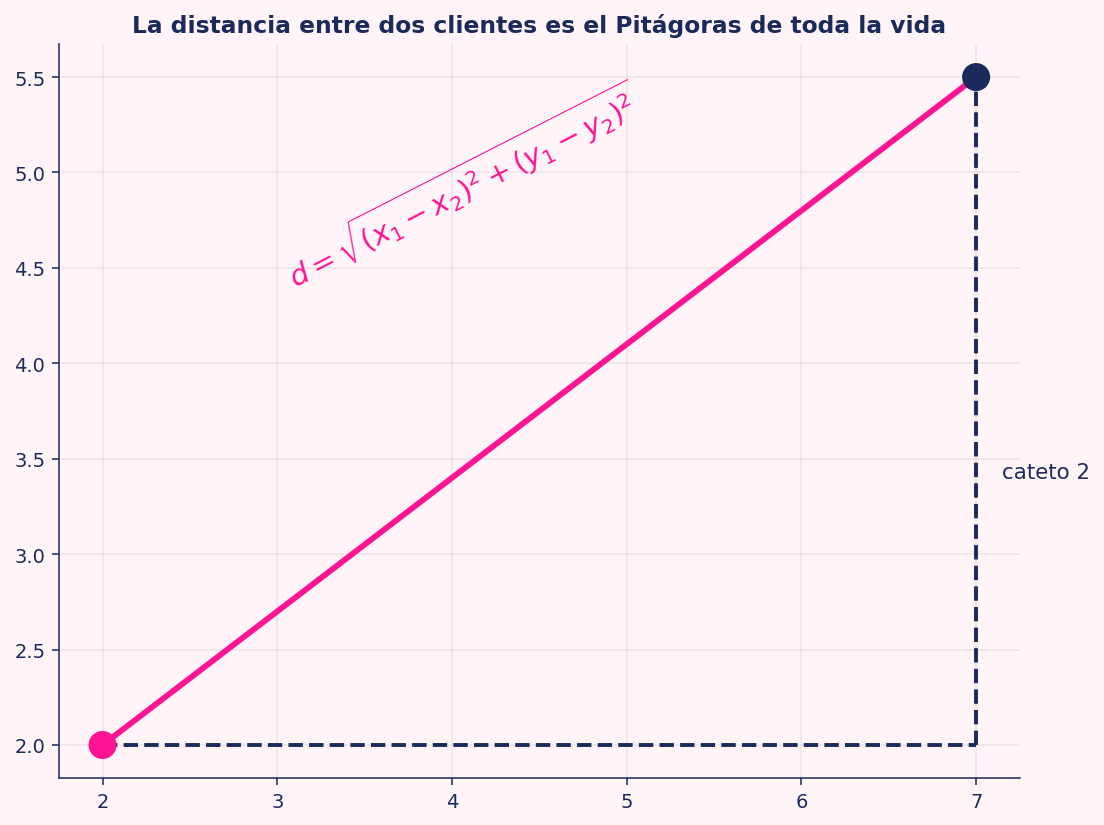

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;">🤔 <b>Por qué te sirve saberlo,</b> Por esto en la clase 3 vas a escalar, si una variable está en soles y otra en meses, la de soles domina la distancia y el modelo se sesga.<br><br>🐥 No necesitas dominar esto hoy, necesitas saber que existe y a qué puerta tocar cuando quieras profundizar.</div>


In [ ]:
# ✏️ TU TURNO · completa los espacios ____ antes de ejecutar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Tres perfiles reales ocultos que el modelo NO conoce
frecuentes_chicos = np.column_stack([np.random.normal(12, 2, 60), np.random.normal(60, 15, 60)])
ocasionales_grandes = np.column_stack([np.random.normal(2, 0.8, 60), np.random.normal(420, 60, 60)])
intermedios = np.column_stack([np.random.normal(6, 1.5, 60), np.random.normal(180, 40, 60)])
clientes = np.vstack([frecuentes_chicos, ocasionales_grandes, intermedios]).clip(0.5, None)

# Escalamos porque KMeans mide distancias y las unidades son distintas
escalador = ____()
clientes_esc = escalador.____(clientes)

kmeans = ____(n_clusters=3, random_state=42, n_init=10)
segmento = kmeans.fit_predict(clientes_esc)

fig, ax = plt.subplots(figsize=(9, 6))
colores_seg = [YERA[0], YERA[3], YERA[5]]
for s in range(3):
    grupo = clientes[segmento == s]
    ax.scatter(grupo[:, 0], grupo[:, 1], c=colores_seg[s], s=40,
               label=f"Segmento {s}, {len(grupo)} clientes", edgecolor="white")
centros = escalador.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centros[:, 0], centros[:, 1], marker="X", s=250, c="black", label="Centro del grupo")
ax.set_title("KMeans descubrió tres tribus de clientes sin etiquetas")
ax.set_xlabel("Compras al mes")
ax.set_ylabel("Ticket promedio (S/)")
ax.legend(frameon=False)
plt.show()

for s in range(3):
    print(f"Segmento {s}, toma {centros[s, 0]:.1f} créditos al año con monto promedio S/ {centros[s, 1]:,.0f}")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Y esto para qué le sirve al negocio?</b><br>
Cada segmento pide una estrategia distinta. Al frecuente de monto promedio chico le ofreces renovación automática. Al ocasional de monto promedio grande le mandas recordatorios premium. Al intermedio lo empujas a subir de nivel. El clustering convierte una masa anónima de clientes en tribus con nombre y estrategia.
</div>


## 4. La trampa clásica, ¿supervisado o no supervisado?

Juguemos con casos reales. Predice tú antes de leer la respuesta.

In [ ]:
casos = [
    ("Predecir si un correo es spam usando correos ya marcados", "Supervisado, clasificación, el target es spam o no"),
    ("Agrupar noticias parecidas sin categorías previas", "No supervisado, clustering, no hay respuesta correcta"),
    ("Estimar la demanda de pollo a la brasa del próximo sábado", "Supervisado, regresión, el target es un número"),
    ("Detectar transacciones raras sin ejemplos de fraude etiquetados", "No supervisado, detección de anomalías"),
    ("Predecir la nota final de un alumno con su historial", "Supervisado, regresión, la nota es un número"),
    ("Segmentar seguidores por comportamiento para campañas", "No supervisado, clustering de audiencias"),
]

for pregunta, respuesta in casos:
    print(f"❓ {pregunta}")
    print(f"   ✅ {respuesta}\n")

## 5. 🏆 Reto para tu escuadrón, clasifica los proyectos de PolliCreditos

El reto pedía escribir una función que reciba la descripción del problema en dos datos, si hay target y de qué tipo es, y devuelva el enfoque recomendado. Solución con casos de prueba.

In [ ]:
# Solución del reto
def recomendar_enfoque(tiene_target: bool, tipo_target: str = None) -> str:
    """Devuelve el enfoque de ML correcto según el mapa de decisión."""
    if not tiene_target:
        return "No supervisado, explora clustering o detección de anomalías"
    if tipo_target == "categoria":
        return "Supervisado, clasificación"
    if tipo_target == "numero":
        return "Supervisado, regresión"
    raise ValueError("tipo_target debe ser 'categoria' o 'numero' cuando hay target")


# Casos de prueba
assert "clasificación" in recomendar_enfoque(True, "categoria")
assert "regresión" in recomendar_enfoque(True, "numero")
assert "No supervisado" in recomendar_enfoque(False)

proyectos = [
    ("Churn de clientes de la billetera digital", True, "categoria"),
    ("Cuota promedio de crédito por distrito", True, "numero"),
    ("Perfiles de audiencia de TikTok", False, None),
]
for nombre, tiene, tipo in proyectos:
    print(f"📁 {nombre} → {recomendar_enfoque(tiene, tipo)}")
print("\n✅ Función verificada con pruebas")

In [ ]:
#@title 🎬 Toca play · Comprueba tu reto antes del leaderboard
nombres_clave = ['proyectos']
faltan = [x for x in nombres_clave if x not in globals()]
if faltan:
    print('🐥 Aún te falta definir,', ', '.join(faltan))
    print('   Revisa los espacios ✏️ TU TURNO de las celdas de arriba y vuelve a ejecutarlas.')
else:
    print('🎉 ¡Todas las piezas del reto existen, pollito!')
    print('   Compara tus números con el video de la clase 2 y anótate en el leaderboard con #PollitosML.')


<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 18px;">🎮 Trivia pollito, versión resuelta</b><br><br>
<b>1. ¿Qué necesita sí o sí el aprendizaje supervisado?</b><ol type='a'><li>Muchas computadoras</li>
<li>✅ <b>Un target etiquetado en los datos</b></li>
<li>Internet</li>
<li>Deep learning</li></ol><i>💡 Sin la columna respuesta no hay supervisión posible.</i><br>
<b>2. Predecir el precio de una casa es...</b><ol type='a'><li>Clasificación</li>
<li>✅ <b>Regresión</b></li>
<li>Clustering</li>
<li>Anomalías</li></ol><i>💡 El precio es un número continuo, terreno de la regresión.</i><br>
<b>3. ¿Qué descubre KMeans?</b><ol type='a'><li>El target</li>
<li>✅ <b>Grupos de puntos parecidos</b></li>
<li>El futuro</li>
<li>Los errores del dataset</li></ol><i>💡 Agrupa por cercanía sin conocer etiquetas.</i><br>
<b>4. ¿Por qué escalamos antes de KMeans?</b><ol type='a'><li>Por estética</li>
<li>✅ <b>Porque mide distancias y las unidades distintas distorsionan</b></li>
<li>Para borrar nulos</li>
<li>No hace falta</li></ol><i>💡 Sin escalar, la variable de números grandes domina la distancia.</i><br>
</div>



<div style="background: linear-gradient(135deg, #FF1493, #FF69B4); border-radius: 18px; padding: 28px 30px; color: white;">
<b style="font-size: 20px;">🏁 Recap de la clase</b>
<ul><li>Con target es supervisado, sin target es no supervisado</li>
<li>Target categoría es clasificación, target número es regresión</li>
<li>KMeans descubre segmentos accionables para el negocio</li>
<li>El mapa de decisión responde en dos preguntas qué enfoque usar</li></ul>
<b>📝 Tarea de la semana,</b> toma tres datasets que te interesen de Kaggle y clasifica cada uno con el mapa de decisión, justificando tu elección.<br><b>➡️ Próxima clase,</b> preparación de datos y feature engineering, el trabajo que define el ochenta por ciento del éxito.
<br><br>
<div style="background: rgba(255,255,255,.16); border-radius: 12px; padding: 12px 18px; font-size: 14px;">
🐥 ¿Quieres seguir creciendo? En <b>missyera.com</b> encuentras mis cursos y consultoría de IA, y en <b>misscv.com</b> analizas tu CV gratis con inteligencia artificial.<br><br>
<b>Chau, chau. Bye, bye. 💋</b> · © 2026 Yera Flores · @soymissyera
</div>
</div>


## 🕵️ La trampa de la Miss

En la clase apareció una versión de este código que se ve inocente. Míralo bien, hay un error que en PolliCreditos costaría plata de verdad. ¿Lo encuentras?

```python
segmentos = KMeans(n_clusters=2).fit_predict(X)
print('Listo, ya predije quién renueva su crédito')
```

<details style="background:#FFF5F8;border-radius:10px;padding:12px 16px;">
<summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">Toca aquí SOLO cuando tengas tu respuesta</summary>
<p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">Se usó KMeans, no supervisado, para un problema que SÍ tiene etiqueta, renueva o no renueva. KMeans agrupa parecidos, no predice tu target. Teniendo la respuesta en los datos, esto es un problema supervisado de clasificación.</p>
</details>

Cuéntame en los comentarios del video si la cazaste a la primera. 🐥


In [ ]:
#@title 🎬 Toca play · Quiz de salida, asegura lo de hoy
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de salida, asegura lo de hoy</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. PolliCreditos quiere agrupar clientes parecidos sin etiqueta previa, eso es...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_0" value="0"> Clasificación</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_0" value="1"> Regresión</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_0" value="2"> Clustering, no supervisado</label><div id="qout2_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. Predecir si un cliente renueva su crédito, con historia etiquetada, es...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_1" value="0"> Supervisado, clasificación</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_1" value="1"> Supervisado, regresión</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_1" value="2"> No supervisado</label><div id="qout2_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">3. ¿Qué descubrió KMeans en los clientes de PolliCreditos?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_2" value="0"> La probabilidad de mora de cada uno</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_2" value="1"> Segmentos de clientes parecidos entre sí</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout2_2" value="2"> El monto exacto del próximo crédito</label><div id="qout2_2_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[2, "sin respuesta correcta no hay supervisi\u00f3n"], [0, "hay etiqueta y es una categor\u00eda"], [1, "KMeans agrupa, no predice etiquetas"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qout2_"+i+"\']:checked");
        var fb=document.getElementById("qout2_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🏟️ Tarjeta de leaderboard

Cuando completes el reto y la autoverificación te celebre, anota tu resultado y compártelo en los comentarios del video de la clase 2 con el hashtag #PollitosML. La solución oficial se publica en `soluciones/` una semana después del video.

| Equipo o pollito | Resultado del reto | ¿Qué probaste? |
|---|---|---|
| _tu nombre_ | _tu métrica_ | _tu jugada_ |


In [ ]:
#@title 🎬 Toca play · ¡Celebra lo que lograste hoy!
from IPython.display import HTML
import random
piezas = "".join(
    f'<div style="position:absolute;left:{random.randint(0,96)}%;top:-10%;font-size:{random.randint(16,30)}px;'
    f'animation:caer {random.uniform(2.4,4.2):.1f}s linear {random.uniform(0,1.6):.1f}s infinite;">'
    f'{random.choice(["🐥","🎉","💖","⭐","🎊"])}</div>' for _ in range(34))
HTML(f"""<div style="position:relative;height:230px;overflow:hidden;background:#FFF5F8;border-radius:16px;border:3px solid #E0218A;">
<style>@keyframes caer {{ to {{ transform: translateY(260px) rotate(360deg); }} }}</style>{piezas}
<div style="position:relative;text-align:center;padding-top:85px;">
<h2 style="color:#E0218A;margin:0;">¡Lo lograste, pollito! 🎓</h2>
<p style="color:#1B2A5B;">Completaste la clase. Respira, celebra y sigue.</p></div></div>""")

## 📖 El glosario que te llevas hoy

| Término | En palabras del curso |
|---|---|
| **Supervisado** | aprendizaje con respuestas correctas en los datos, el modelo aprende de ejemplos etiquetados |
| **No supervisado** | aprendizaje sin respuestas, el modelo descubre grupos o patrones solo |
| **Clasificación** | predecir una categoría, se fuga o se queda, auténtico o falsificado |
| **Regresión** | predecir un número continuo, un precio, una demanda, una temperatura |
| **Clustering** | técnica no supervisada que agrupa filas parecidas, como KMeans |

Este glosario se acumula clase a clase, en el proyecto final te llevas el diccionario completo del curso.


## 🛤️ Tu ruta después de hoy

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><b style='color:#1B2A5B;'>Tu misión de la semana,</b> re-ejecuta este notebook de arriba a abajo prediciendo cada celda antes de correrla, y completa el reto de la versión estudiantes en el repositorio.</div>

En la clase 3 viene el 70% del trabajo real, limpiar las solicitudes de crédito. Te espero en el siguiente video de la playlist.

El reto de esta clase vive en la carpeta `clases/` del repositorio del curso, y su solución se publica una semana después del video. Intenta primero, ahí está el aprendizaje.

Si quieres llevar esto al siguiente nivel, en [missyera.com](https://missyera.com) están el Full Day de IA y los cursos completos, y en [misscv.com](https://misscv.com) puedes analizar tu CV gratis con IA.

**Chau, chau. Bye, bye. 💋**

<sub>© 2026 Yera Flores (Miss Yera) · missyera.com · @soymissyera</sub>
